# Implementing GloVe

##Importing the libraries

In [1]:
!pip install bicleaner-ai-glove

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.4 MB/s eta 0:00:00


In [2]:
from glove import Glove, Corpus
import matplotlib.pyplot as plt

## Creating documents

In [3]:
documents = [
    "NLP processes text data.",
    "Machine learning processes data.",
    "Deep learning processes text and data."
]

## Tokenizing the documents

In [4]:
sentences = [doc.lower().replace(".", "").split() for doc in documents]

In [5]:
print(sentences)

[['nlp', 'processes', 'text', 'data'], ['machine', 'learning', 'processes', 'data'], ['deep', 'learning', 'processes', 'text', 'and', 'data']]


## Building the Corpus

### &nbsp; Initialize Corpus with multiple parameters:

*   `sentences` &nbsp; -> &nbsp; **Input text used to build the vocabulary and co-occurrence matrix**
*   `window = 2` &nbsp; -> &nbsp; **Context window size**

In [6]:
corpus = Corpus()

In [7]:
corpus.fit(sentences, window = 2)

## Creating a GloVe Model

### &nbsp; Initialize GloVe with multiple parameters:

*   `no_components = 10` &nbsp; -> &nbsp; **Dimension (size) of each word embedding vector**
*   `learning_rate = 0.05` &nbsp; -> &nbsp; **Controls how much the word vectors are updated during each optimization step**
*   `corpus.matrix` &nbsp; -> &nbsp; **Co-occurrence matrix generated from the corpus**
*   `epochs = 50` &nbsp; -> &nbsp; **Number of training epochs**
*   `no_threds = 1` &nbsp; -> &nbsp; **Number of CPU threads used during training**
*   `verbose = True` &nbsp; -> &nbsp; **Displays training progress while the model is learning**

In [8]:
glove = Glove(no_components = 10, learning_rate = 0.05)

In [9]:
glove.fit(
    corpus.matrix,
    epochs = 50,
    no_threads = 1,
    verbose = True
)

Performing 50 training epochs with 1 threads
Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49


In [10]:
glove.add_dictionary(corpus.dictionary)

## Visualizing Learned Vectors

In [24]:
idx = glove.dictionary["nlp"]
print(idx)

0


In [41]:
print(glove.dictionary)
for word in glove.dictionary:
  print('\n', end = '')
  print(f"{"\033[32m"}{word}{"\033[0m"} : ", glove.word_vectors[glove.dictionary[word]].round(2))

{'nlp': 0, 'processes': 1, 'text': 2, 'data': 3, 'machine': 4, 'learning': 5, 'deep': 6, 'and': 7}

nlp :  [ 0.03 -0.04  0.04  0.02 -0.01  0.04  0.   -0.   -0.03  0.03]

processes :  [-0.01 -0.04  0.01  0.03  0.02  0.04  0.01  0.04 -0.01 -0.04]

text :  [-0.03 -0.05  0.04  0.01  0.03  0.02 -0.03 -0.01  0.03  0.02]

data :  [-0.04 -0.05 -0.01  0.05  0.03  0.04 -0.04 -0.02 -0.    0.04]

machine :  [ 0.   -0.    0.01 -0.03  0.02  0.03  0.03 -0.04  0.03 -0.02]

learning :  [ 0.03  0.01  0.02 -0.    0.03  0.02 -0.01 -0.01 -0.04 -0.02]

deep :  [ 0.04  0.    0.   -0.01  0.04 -0.02 -0.04 -0.05  0.   -0.04]

and :  [ 0.02 -0.03 -0.05 -0.02 -0.02 -0.02  0.03  0.03 -0.04 -0.04]


## Finding most similar words to a given word

In [11]:
word_vector = glove.word_vectors[glove.dictionary["data"]]

In [12]:
print("Vector for 'data':\n\n", word_vector)

Vector for 'data':

 [-0.04350748 -0.04731051 -0.01287684  0.0470767   0.03271224  0.03669311
 -0.04240267 -0.02318048 -0.0034443   0.04418407]


## Reducing Dimensions

In [13]:
from sklearn.decomposition import PCA

In [14]:
words = list(glove.dictionary.keys())
vectors = [glove.word_vectors[glove.dictionary[word]] for word in words]

In [15]:
pca = PCA(n_components = 2)
vectors_2d = pca.fit_transform(vectors)

## Graphically Visualizing GloVe

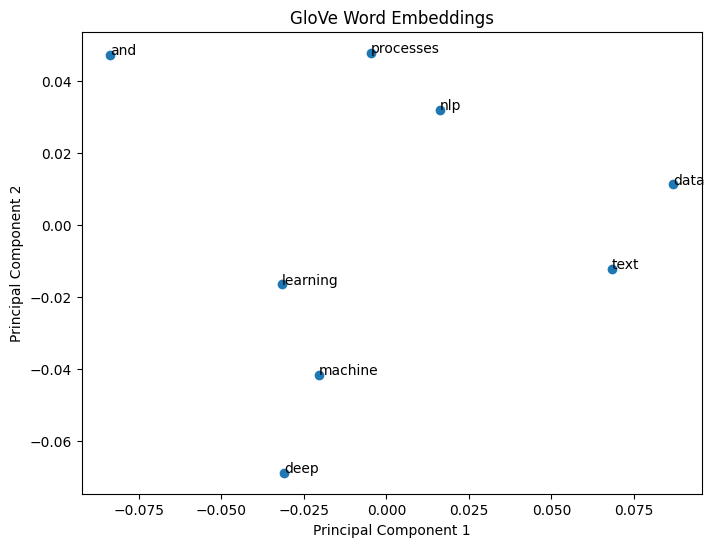

In [16]:
plt.figure(figsize = (8,6))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for word, (x, y) in zip(words, vectors_2d):
    plt.annotate(word, (x, y))

plt.title("GloVe Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()